In [10]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn import set_config
from sklearn.model_selection import (train_test_split, StratifiedShuffleSplit,
                                      cross_val_score, GridSearchCV, RandomizedSearchCV)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder, StandardScaler,
                                    MinMaxScaler, FunctionTransformer, PowerTransformer)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import (ColumnTransformer, TransformedTargetRegressor,
                              make_column_selector, make_column_transformer)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel
import sklearn


# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('data')

In [11]:
from zipfile import ZipFile

zip_path = DATA_PATH / "playground-series-s6e1.zip"
extract_dir = DATA_PATH / "playground-series-s6e1"

if not zip_path.exists():
    raise FileNotFoundError(f"Zip file not found: {zip_path}")

# Extract the competition files into a dedicated folder inside ../data
extract_dir.mkdir(parents=True, exist_ok=True)
with ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall(extract_dir)

train_csv_path = extract_dir / "train.csv"
if not train_csv_path.exists():
    raise FileNotFoundError(f"train.csv not found after extraction: {train_csv_path}")

# Polars is preferred for data loading and wrangling in this repo
train_df = pl.read_csv(train_csv_path)



In [12]:
train_df.head()

id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
i64,i64,str,str,f64,f64,str,f64,str,str,str,str,f64
0,21,"""female""","""b.sc""",7.91,98.8,"""no""",4.9,"""average""","""online videos""","""low""","""easy""",78.3
1,18,"""other""","""diploma""",4.95,94.8,"""yes""",4.7,"""poor""","""self-study""","""medium""","""moderate""",46.7
2,20,"""female""","""b.sc""",4.68,92.6,"""yes""",5.8,"""poor""","""coaching""","""high""","""moderate""",99.0
3,19,"""male""","""b.sc""",2.0,49.5,"""yes""",8.3,"""average""","""group study""","""high""","""moderate""",63.9
4,23,"""male""","""bca""",7.65,86.9,"""yes""",9.6,"""good""","""self-study""","""high""","""easy""",100.0


In [13]:
train_df.to_pandas().info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  str    
 3   course            630000 non-null  str    
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  str    
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  str    
 9   study_method      630000 non-null  str    
 10  facility_rating   630000 non-null  str    
 11  exam_difficulty   630000 non-null  str    
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), str(7)
memory usage: 84.8 MB


No existe nulos en este dataset por lo que las inyecciones de nulos no son necesarios. Revsar la distribución de las columnas numéricas es importante para saber si es necesario hacer alguna transformación a los datos.

In [14]:
import polars.selectors as cs

train_df.select(cs.numeric()).describe()

statistic,id,age,study_hours,class_attendance,sleep_hours,exam_score
str,f64,f64,f64,f64,f64,f64
"""count""",630000.0,630000.0,630000.0,630000.0,630000.0,630000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",314999.5,20.545821,4.002337,71.987261,7.072758,62.506672
"""std""",181865.479132,2.260238,2.35988,17.430098,1.744811,18.916884
"""min""",0.0,17.0,0.08,40.6,4.1,19.599
"""25%""",157500.0,19.0,1.97,57.0,5.6,48.8
"""50%""",315000.0,21.0,4.0,72.6,7.1,62.6
"""75%""",472499.0,23.0,6.05,87.2,8.6,76.3
"""max""",629999.0,24.0,7.91,99.4,9.9,100.0


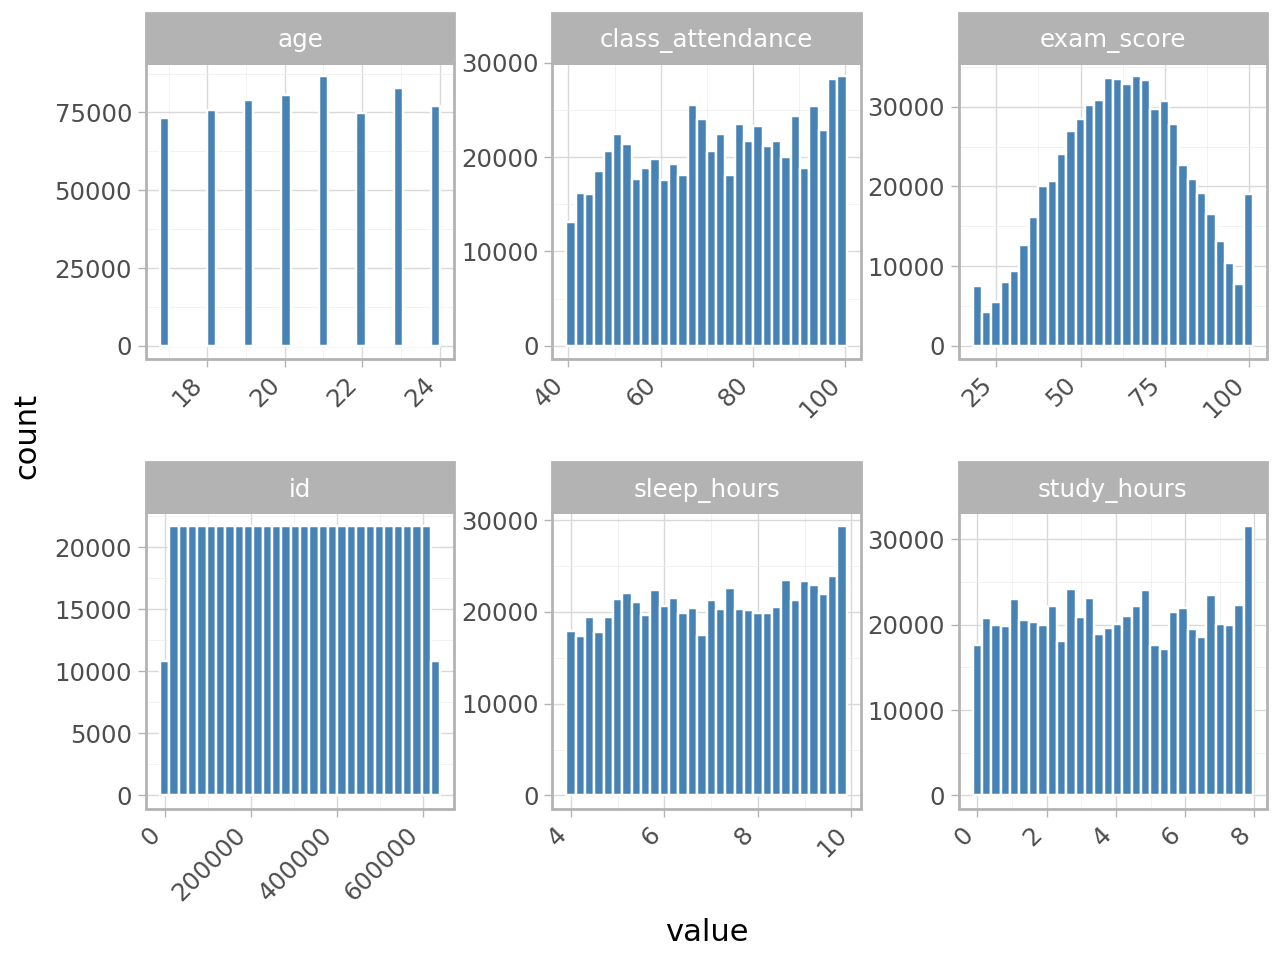

In [15]:
from plotnine import *
# Seleccionamos columnas numéricas en Polars
train_melted = (
    train_df
    .select(cs.numeric())
    .to_pandas()
    .melt()
)

(
    ggplot(train_melted, aes(x="value"))
    + geom_histogram(bins=30, fill="steelblue", color="white")
    + facet_wrap("~variable", scales="free")
    + theme_light()
    + theme(axis_text_x=element_text(rotation=45, hjust=1))
)

## Buscando correlaciones

In [16]:
corr_matrix = train_df.to_pandas().corr(numeric_only=True)

In [17]:
corr_matrix["exam_score"].sort_values(ascending=False)

exam_score          1.000000
study_hours         0.762267
class_attendance    0.360954
sleep_hours         0.167410
age                 0.010472
id                  0.000372
Name: exam_score, dtype: float64

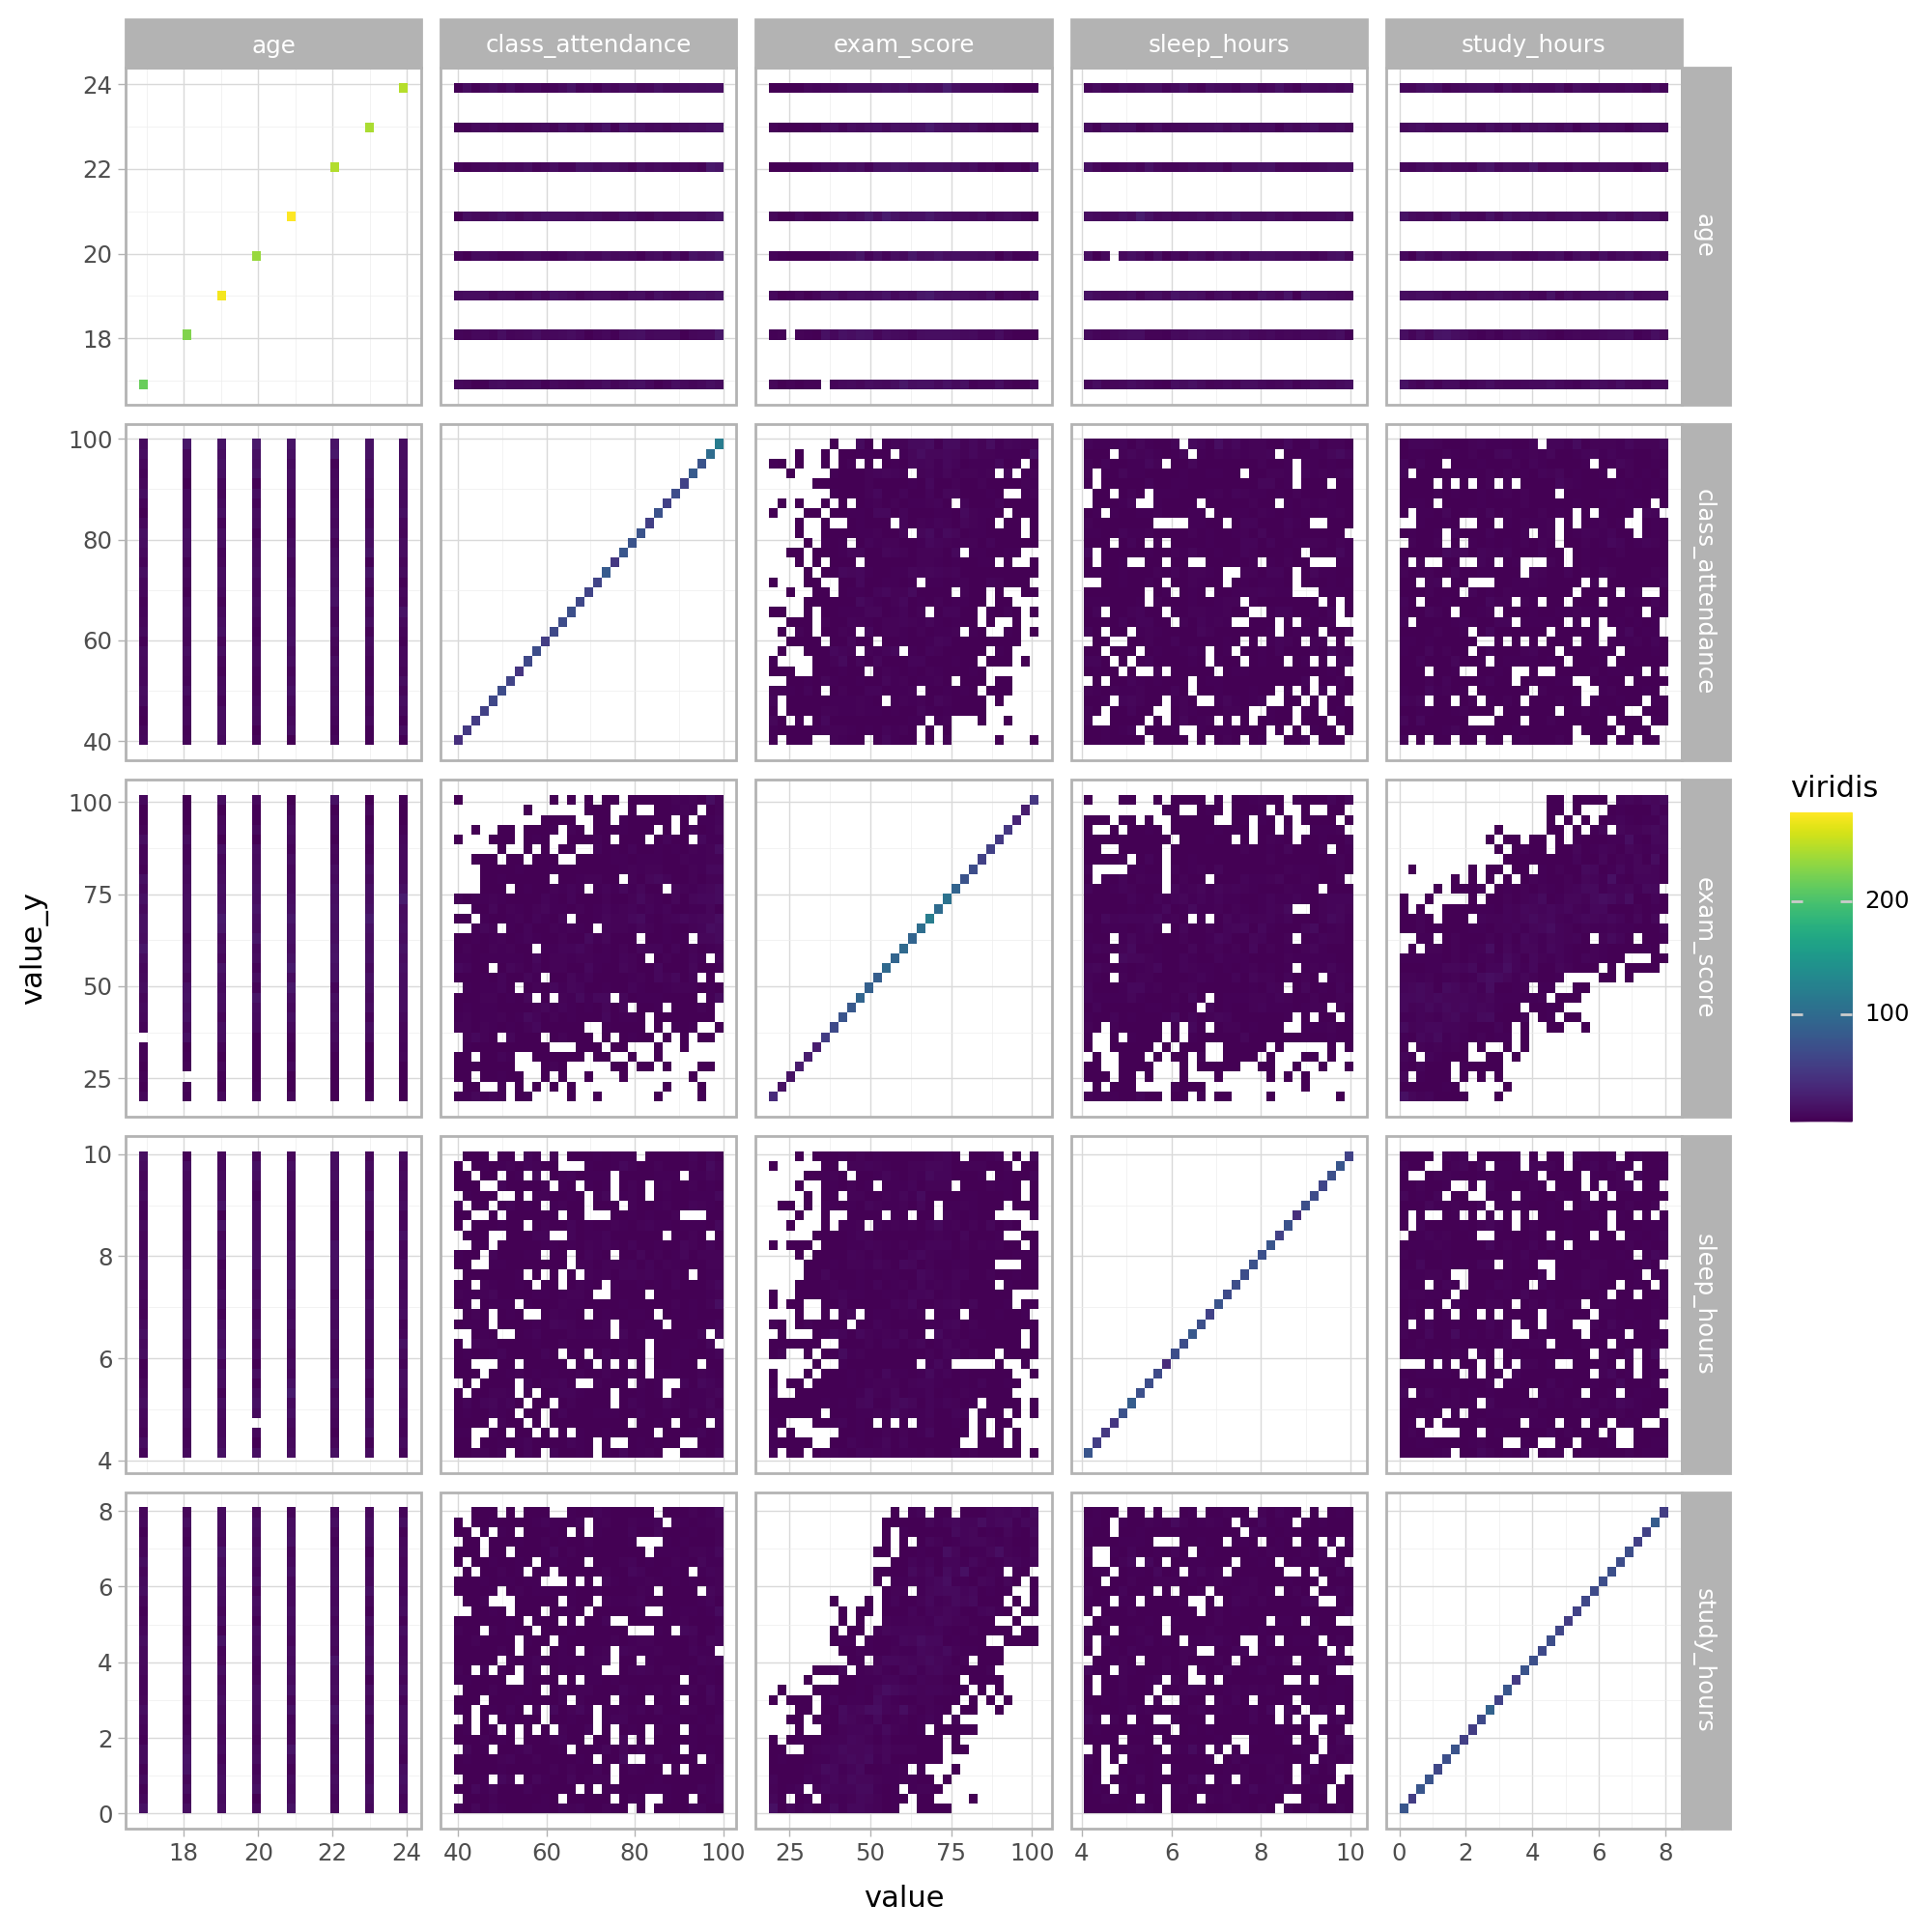

In [18]:

attributes = train_df.select(cs.numeric()).columns
# Keep only numeric features for the matrix (exclude id as a feature)
numeric_cols = [c for c in attributes if c != "id"]

# Long format once, then self-join by id to build all variable pairs
# Muestreo previo para reducir la carga en el join y el plot
df_sample = train_df.select(["id", *numeric_cols]).sample(n=2000, seed=42)

long_df = df_sample.unpivot(
    index="id",
    variable_name="variable",
    value_name="value"
)

df_pair = long_df.join(long_df, on="id", suffix="_y")

(
    ggplot(df_pair, aes(x="value", y="value_y"))
    + geom_bin2d(bins=30) # En lugar de geom_point
    + facet_grid("variable_y ~ variable", scales="free")
    + scale_fill_cmap(name="viridis")
    + theme_light()
    + theme(figure_size=(10, 10))
)


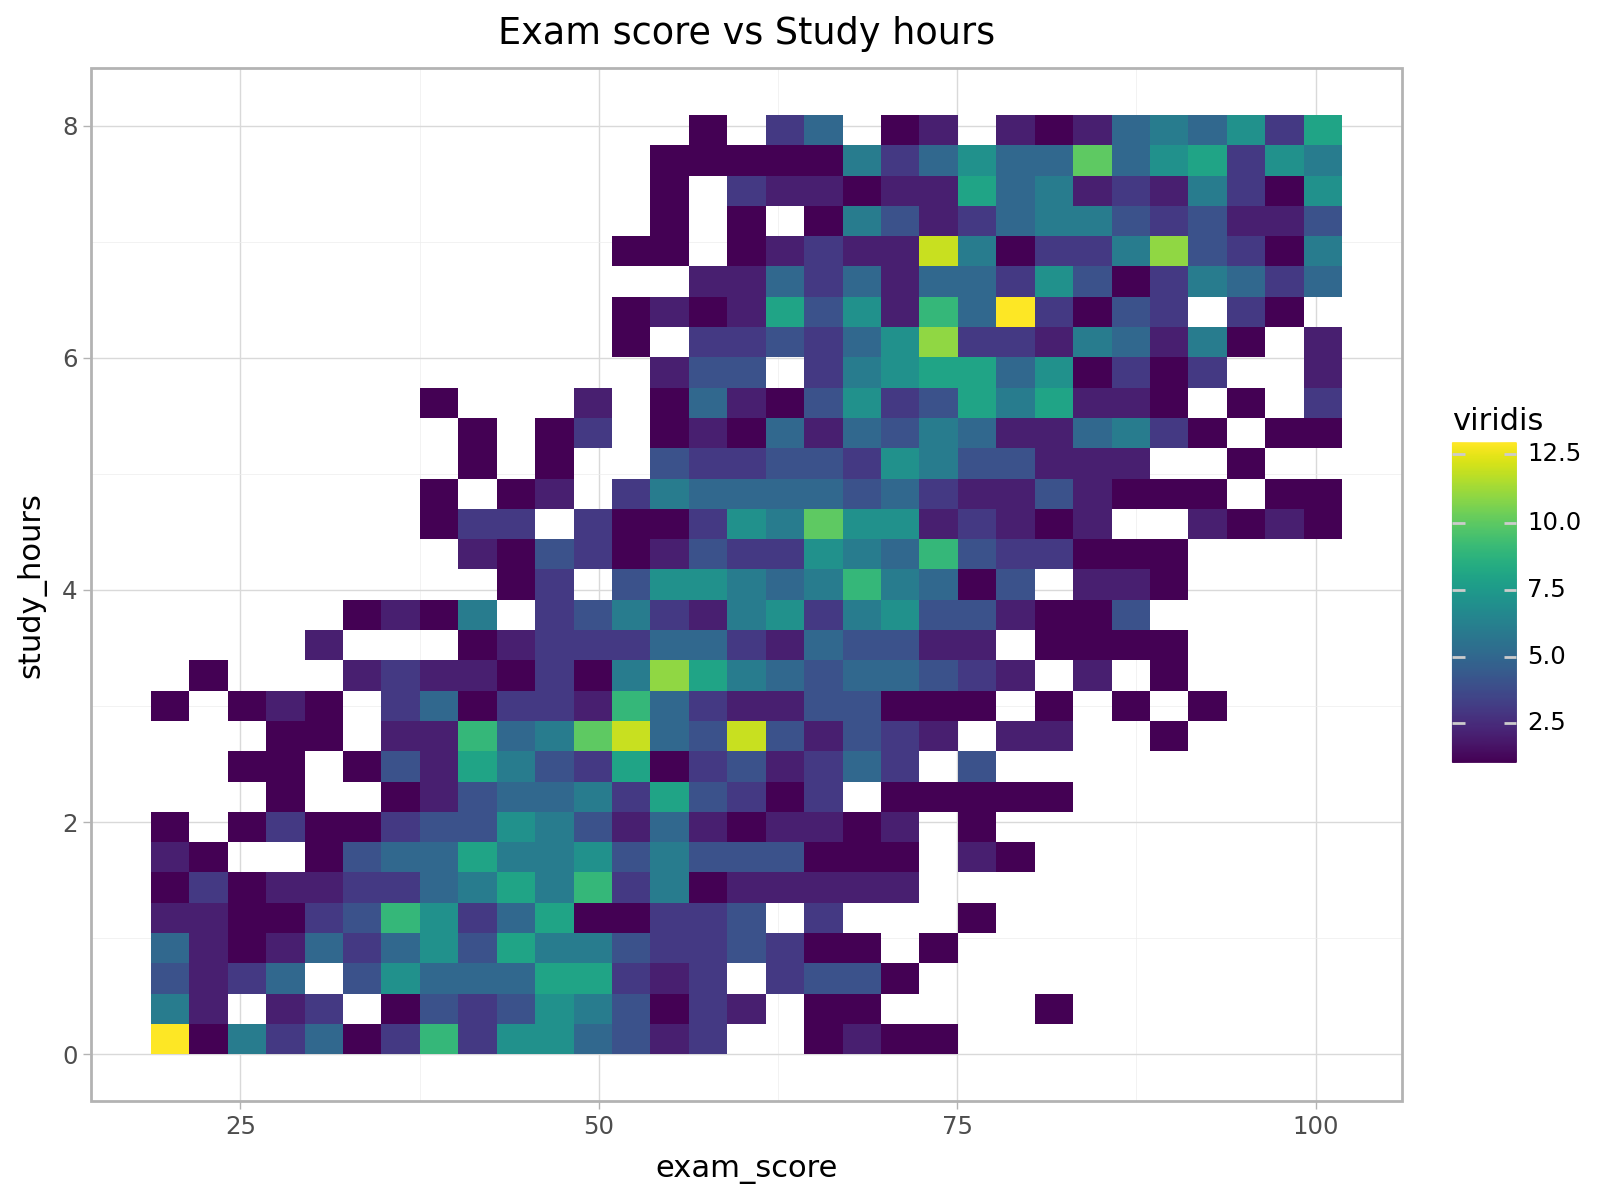

In [19]:
exam_vs_study = (
    df_pair
    .filter(
        (pl.col("variable") == "exam_score") &
        (pl.col("variable_y") == "study_hours")
    )
    .to_pandas()
)

(
    ggplot(exam_vs_study, aes(x="value", y="value_y"))
    + geom_bin2d(bins=30)
    + scale_fill_cmap(name="viridis")
    + labs(x="exam_score", y="study_hours", title="Exam score vs Study hours")
    + theme_light()
    + theme(figure_size=(8, 6))
)

Se observa que las horas estudiadas en gran medida tienen la mejor correlación con el puntaje de examen, atención en clase también aunque en menor medida, edad la verdad que si es un tanto despreciable.

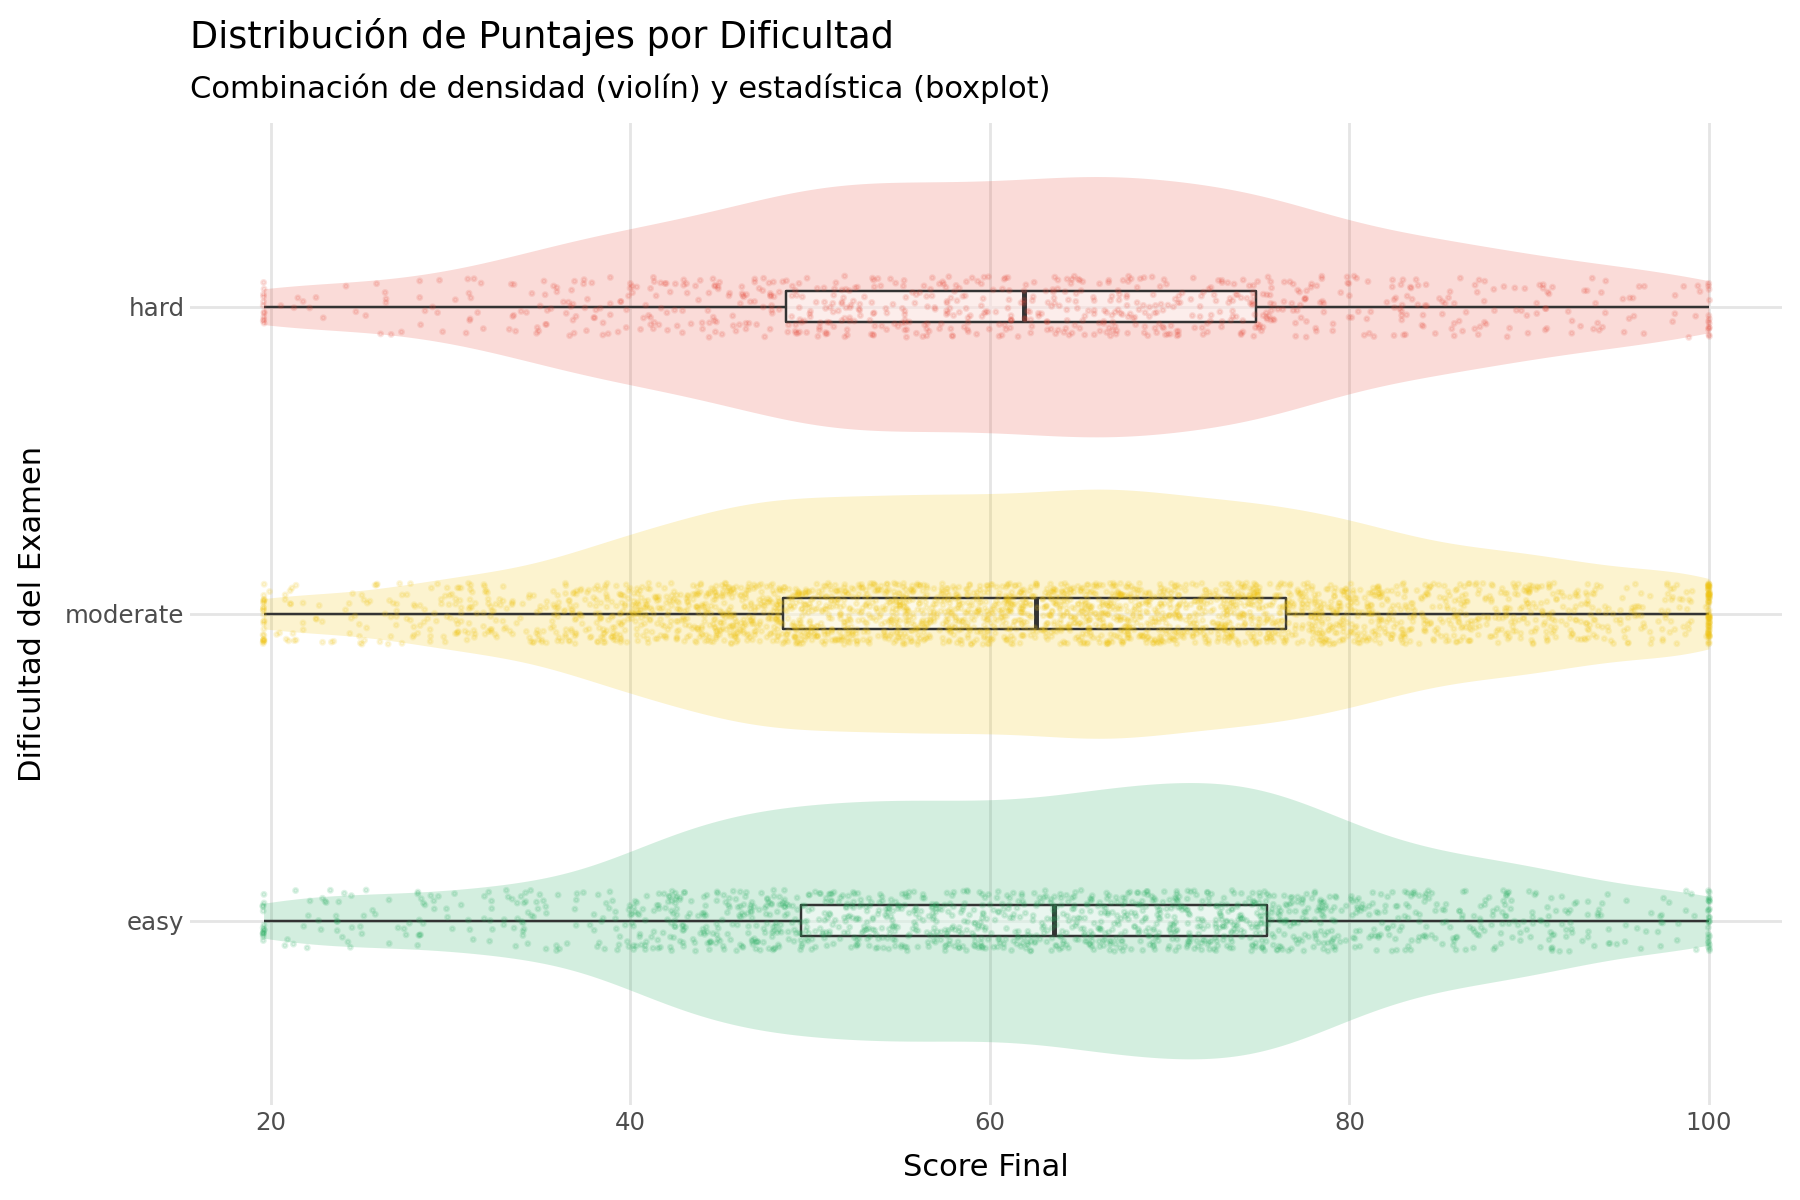

In [20]:
import polars as pl
import pandas as pd
from plotnine import *

# 1. Definimos ebl orden deseado
difficulty_order = ["easy", "moderate", "hard"]

# 2. Selección y conversión limpia
# Mantenemos Polars para la carga y muestreo (que es más rápido)
plot_data = (
    train_df
    .select(["exam_score", "exam_difficulty", "sleep_hours"])
    .sample(n=5000, seed=42)
    .to_pandas()
)

# 3. Forzamos el orden en Pandas (esto es lo que Plotnine usará para el eje)
plot_data["exam_difficulty"] = pd.Categorical(
    plot_data["exam_difficulty"], 
    categories=difficulty_order, 
    ordered=True
)

# 4. Construcción del gráfico refinado
(
    ggplot(plot_data, aes(x="exam_difficulty", y="exam_score", fill="exam_difficulty"))
    # Capa de densidad (Violín)
    + geom_violin(alpha=0.2, color=None, show_legend=False)
    # Capa estadística (Boxplot) para ver medianas y cuartiles
    + geom_boxplot(width=0.1, fill="white", alpha=0.5, outlier_alpha=0)
    # Capa de datos crudos (Jitter) con puntos muy pequeños
    + geom_jitter(aes(color="exam_difficulty"), width=0.1, alpha=0.15, size=0.4)
    # Colores semánticos: Verde (Fácil) -> Rojo (Difícil)
    + scale_fill_manual(values={"easy": "#27ae60", "moderate": "#f1c40f", "hard": "#e74c3c"})
    + scale_color_manual(values={"easy": "#27ae60", "moderate": "#f1c40f", "hard": "#e74c3c"})
    + coord_flip() # Eje X horizontal para mejor lectura
    + labs(
        title="Distribución de Puntajes por Dificultad",
        subtitle="Combinación de densidad (violín) y estadística (boxplot)",
        x="Dificultad del Examen",
        y="Score Final"
    )
    + theme_minimal()
    + theme(
        figure_size=(9, 6),
        legend_position="none",
        panel_grid_minor=element_blank()
    )
)

Las distribuiciones son muy parecidas en cuanto a las categorías de día

In [21]:
# declarar cat cols
cat_cols = train_df.select(cs.string()).columns

# Iterar sobre cada columna categórica y calcular estadísticas de exam_score
for cat in cat_cols:
    group_df = train_df.group_by(cat).agg(
        pl.col("exam_score").mean().alias("exam_score_mean"),
        pl.col("exam_score").median().alias("exam_score_median"),
        pl.col("exam_score").std().alias("exam_score_std"),
        pl.len().alias("count")  # Para saber cuántos registros hay por categoría
    ).select(
        pl.col(cat),
        pl.col("exam_score_mean").round(2),
        pl.col("exam_score_median").round(2),
        pl.col("exam_score_std").round(2),
        pl.col("count")
    ).sort("exam_score_mean", descending=True)
    print("\n")
    print(f"Exam score stats by {cat}:")
    print(group_df)



Exam score stats by gender:
shape: (3, 5)
┌────────┬─────────────────┬───────────────────┬────────────────┬────────┐
│ gender ┆ exam_score_mean ┆ exam_score_median ┆ exam_score_std ┆ count  │
│ ---    ┆ ---             ┆ ---               ┆ ---            ┆ ---    │
│ str    ┆ f64             ┆ f64               ┆ f64            ┆ u32    │
╞════════╪═════════════════╪═══════════════════╪════════════════╪════════╡
│ other  ┆ 62.78           ┆ 62.6              ┆ 19.09          ┆ 211097 │
│ female ┆ 62.56           ┆ 62.5              ┆ 18.89          ┆ 208310 │
│ male   ┆ 62.18           ┆ 62.5              ┆ 18.77          ┆ 210593 │
└────────┴─────────────────┴───────────────────┴────────────────┴────────┘


Exam score stats by course:
shape: (7, 5)
┌─────────┬─────────────────┬───────────────────┬────────────────┬────────┐
│ course  ┆ exam_score_mean ┆ exam_score_median ┆ exam_score_std ┆ count  │
│ ---     ┆ ---             ┆ ---               ┆ ---            ┆ ---    │
│ str    

Aquí se observa infomación bastante valiosa como es ver los estadisticos agrupados por las variables categoricas:

 - La columna **exam_difficulty** cuenta con 3 categorías, es una variable **ordinal**, curiosamente cuando es hard el puntaje de examen es más alto, que cuando es easy, esto puede ser porque los estudiantes que se sienten más confiados se inscriben a cursos más difíciles, o también puede ser que el curso fácil no es tan fácil como parece. En cualquier caso, esta variable es importante para el modelo.

 - Para el caso de facility_rating, sucede algo similar y más notorio, cuando la calificación es más alta, el puntaje del examen también es más alto, es otra variable importante para el modelo. En este caso en cada categoría la desviación estandar no es tan variable como en la anetrior, **es ordinal**

 - En la columna study_method, esta es una variable **nominal** y se observa que el método de estudio más efectivo es el de grupo, seguido del método individual, al parecer el mejor es el de coaching, tienen desviaciones similares en la variable objetivo, pero el método de grupo tiene un puntaje promedio más alto, es una variable importante para el modelo.

 - En la columna sleep_quality, esta es una variable **ordinal** y se observa que a medida que la calidad del sueño es mejor, el puntaje del examen también es mejor, es una variable importante para el modelo.

 - En la columna internet_access, esta es una variable **binaria** y se observa que los estudiantes con acceso a internet tienen un puntaje de examen promedio más alto que aquellos sin acceso, aunque es muy lijera esa diferencia, es una variable que podría ser importante para el modelo.

 - Siguente, la columna gender, esta variable es **trinaria**, pero se puede convertir en binaria, y se observa que los estudiantes de género femenino tienen un puntaje de examen promedio más alto que los estudiantes de género masculino, aunque la diferencia es muy ligera, es una variable que podría ser importante para el modelo, los no identificados con esos 2 generos tienen un puntaje promedio superior.

 - El curso de estudio también es una variable **nominal** y se observa que el curso de matemáticas tiene un puntaje de examen promedio más alto que el curso de historia, aunque la diferencia es muy ligera, es una variable que podría ser importante para el modelo.|

## Feature Engineering

In [ ]:
def col_ratio(X):
    # Forzamos a que sea 2D antes de operar
    X = np.asarray(X)
    # Operación y REDIMENSIONAMIENTO A 2D (.reshape(-1, 1))
    return (X[:, 0] / np.where(X[:, 1] == 0, 1, X[:, 1])).reshape(-1, 1)

def col_mul_100(X):
    X = np.asarray(X)
    # El .reshape(-1, 1) es el "salvavidas" aquí
    return (X[:, 0] * X[:, 1] / 100).reshape(-1, 1)

def interaction_cat(X):
    X = np.asarray(X).astype(str)
    # Concatenamos y transformamos a 2D
    return np.array([a + "_" + b for a, b in zip(X[:, 0], X[:, 1])]).reshape(-1, 1)

def feature_engineering(df):
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")
    
    # Asegurarse de que las columnas necesarias existan
    required_cols = {"study_hours", "class_attendance", "internet_access", "facility_rating"}
    if not required_cols.issubset(set(df.columns)):
        missing = required_cols - set(df.columns)
        raise ValueError(f"Missing required columns: {missing}")

    # Crear una característica de "estudiante dedicado" basada en horas de estudio y atención
    
    df = df.with_columns(
        ((pl.col("study_hours") > 6) & (pl.col("class_attendance") > 87)).cast(pl.Int8).alias("dedicated_student"),
    )
    return df

In [23]:
train_df.select(["study_hours", "class_attendance"]).describe()

statistic,study_hours,class_attendance
str,f64,f64
"""count""",630000.0,630000.0
"""null_count""",0.0,0.0
"""mean""",4.002337,71.987261
"""std""",2.35988,17.430098
"""min""",0.08,40.6
"""25%""",1.97,57.0
"""50%""",4.0,72.6
"""75%""",6.05,87.2
"""max""",7.91,99.4


## Creando el Pipeline de Preprocesamiento

In [31]:
default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(func=col_ratio, feature_names_out=ratio_name),
        StandardScaler()
)

def mul_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(func=col_mul_100, feature_names_out=lambda ft_in: ["mul_100"]),
        StandardScaler()
)

def interaction_cat_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="most_frequent"),
        FunctionTransformer(func=interaction_cat, feature_names_out=lambda ft_in: ["env_synergy"]),
        OneHotEncoder(handle_unknown="ignore")
    )


nom_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

sleep_order = ["poor", "average", "good"]
facility_order = ["low", "medium", "high"]
exam_difficulty_order = ["easy", "moderate", "hard"]

ord_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OrdinalEncoder(categories=[sleep_order, facility_order, exam_difficulty_order], 
                   handle_unknown="use_encoded_value", unknown_value=-1)
)

# Pipeline para variables asimétricas (Skewed)
# PowerTransformer ya incluye estandarización por defecto (standardize=True)
skew_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    PowerTransformer(method="yeo-johnson") 
)

preprocessor = ColumnTransformer([
    ("attendance_transformed", skew_pipeline, ["class_attendance"]),
    ("eng_index", mul_pipeline(), ["study_hours", "class_attendance"]),
    ("study_sleep_ratio", ratio_pipeline(), ["study_hours", "sleep_hours"]),
    ("env_synergy", interaction_cat_pipeline(), ["internet_access", "facility_rating"]),
    ("ord", ord_pipeline, ["sleep_quality", "facility_rating", "exam_difficulty"]),
    ("nom", nom_pipeline, ["study_method", "gender", "course"]),
    ], 
    remainder=default_num_pipeline
)

# Cross-validation con el pipeline completo
X = train_df.drop(["exam_score", "id"])
y = train_df.select("exam_score").to_series()


In [ ]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])


cv_scores = -cross_val_score(pipeline, 
                            X.to_pandas(), 
                            y, cv=5, 
                            scoring="neg_root_mean_squared_error",
                            n_jobs=-1)
print(f"CV RMSE: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")


CV RMSE: 9.75 ± 0.01


In [20]:
# Randomized Search para LinearRegression (sin parámetros deprecados)
model_params = pipeline.named_steps["model"].get_params()

param_distributions = {
    "model__fit_intercept": [True, False],
    "model__copy_X": [True, False],
}

# Añadir solo parámetros válidos en la versión instalada
if "positive" in model_params:
    param_distributions["model__positive"] = [True, False]

if "tol" in model_params:
    param_distributions["model__tol"] = [1e-6, 1e-4, 1e-2]

rnd_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

rnd_search.fit(X.to_pandas(), y.to_numpy())

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__copy_X': [True, False], 'model__fit_intercept': [True, False], 'model__positive': [True, False], 'model__tol': [1e-06, 0.0001, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation str

In [21]:
rnd_search.best_params_

{'model__tol': 0.0001,
 'model__positive': False,
 'model__fit_intercept': True,
 'model__copy_X': False}

In [25]:
import polars as pl

# 1. Convertir a DataFrame de Polars
cv_res = pl.DataFrame(rnd_search.cv_results_)

# 2. Selección Dinámica Senior
# En lugar de escribir cada 'param_...', usamos selectores de columnas
# Seleccionamos todo lo que empiece con 'param_', los splits, el mean y el std
cv_res = cv_res.select([
    pl.col("^param_.*$"), # Regex para captar todos los hiperparámetros automáticamente
    pl.col("^split[0-9]_test_score$"),
    pl.col("mean_test_score"),
    pl.col("std_test_score"),
    pl.col("rank_test_score")
])

# 3. Limpieza de nombres (Quitar los prefijos de Sklearn)
cv_res = cv_res.rename({
    col: col.replace("param_model__", "").replace("_test_score", "") 
    for col in cv_res.columns
})

# 4. Transformación Correcta de Scores
# Solo multiplicamos por -1 las columnas de error, NO la desviación estándar
error_cols = [c for c in cv_res.columns if "split" in c or "mean" in c]

cv_res = cv_res.with_columns([
    (-pl.col(col)).round(4).alias(col) for col in error_cols
]).with_columns([
    pl.col("std").round(4) # La desviación se queda positiva
])

# 5. Auditoría Final
cv_res.sort("mean").head()

tol,positive,fit_intercept,copy_X,split0,split1,split2,mean,std,rank
f64,bool,bool,bool,f64,f64,f64,f64,f64,i32
0.0001,false,true,false,9.7546,9.7499,9.7563,9.7536,0.0027,1
0.01,false,false,true,9.7546,9.7499,9.7563,9.7536,0.0027,1
0.000001,false,false,true,9.7546,9.7499,9.7563,9.7536,0.0027,1
0.000001,false,false,false,9.7546,9.7499,9.7563,9.7536,0.0027,1
0.01,false,true,true,9.7546,9.7499,9.7563,9.7536,0.0027,1


In [26]:
from scipy.stats import loguniform, randint
from sklearn.model_selection import RandomizedSearchCV

# 1. CORRECCIÓN DE PARÁMETROS: Doble guion bajo '__'
param_distributions = {
    "model__n_estimators": randint(50, 200),        # Reducimos el rango para ahorrar RAM
    "model__max_depth": randint(5, 15),             # Limitamos profundidad para evitar el MemoryError
    "model__min_samples_split": randint(2, 10),
    "model__max_samples": loguniform(0.5, 0.9),     # Truco Senior: usa solo una parte de los datos por árbol
}

# 2. CONFIGURACIÓN DEL BUSCADOR
rnd_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    # TRUCO DE MEMORIA: 
    # Si te sigue dando MemoryError, cambia n_jobs=-1 por n_jobs=2 o n_jobs=None
    n_jobs=4, 
    random_state=42,
    verbose=1,
)

# 3. ENTRENAMIENTO
# Usamos float32 para reducir el peso en memoria si es necesario
rnd_search.fit(X.to_pandas(), y.to_numpy())

print(f"Mejor RMSE: {-rnd_search.best_score_:.2f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejor RMSE: 8.98


In [27]:
import polars as pl

# 1. Convertir a DataFrame de Polars
cv_res = pl.DataFrame(rnd_search.cv_results_)

# 2. Selección Dinámica Senior
cv_res = cv_res.select([
    pl.col("^param_.*$"), # Regex para captar todos los hiperparámetros automáticamente
    pl.col("^split[0-9]_test_score$"),
    pl.col("mean_test_score"),
    pl.col("std_test_score"),
    pl.col("rank_test_score")
])

# 3. Limpieza de nombres (Quitar los prefijos de Sklearn)
cv_res = cv_res.rename({
    col: col.replace("param_model__", "").replace("_test_score", "") 
    for col in cv_res.columns
})

# 4. Transformación Correcta de Scores
# Solo multiplicamos por -1 las columnas de error, NO la desviación estándar
error_cols = [c for c in cv_res.columns if "split" in c or "mean" in c]

cv_res = cv_res.with_columns([
    (-pl.col(col)).round(4).alias(col) for col in error_cols
]).with_columns([
    pl.col("std").round(4) # La desviación se queda positiva
])

# 5. Auditoría Final
cv_res.sort("mean").head()

max_depth,max_samples,min_samples_split,n_estimators,split0,split1,split2,mean,std,rank
i64,f64,i64,i64,f64,f64,f64,f64,f64,i32
13,0.51384,-4,184,9.0068,8.9358,9.007,8.9832,0.0335,1
14,0.513905,-5,64,9.0324,8.9334,9.0459,9.0039,0.0501,2
12,0.710871,-8,171,9.0221,8.9683,9.0262,9.0056,0.0264,3
11,0.798556,-8,156,9.0662,9.0266,9.0655,9.0528,0.0185,4
10,0.502081,-2,98,9.1291,9.0982,9.1298,9.119,0.0147,5


In [ ]:
# test in data\playground-series-s6e1\test.csv

test_df = pl.read_csv(r"data\playground-series-s6e1\test.csv")
rnd_search.best_estimator_.fit(X.to_pandas(), y.to_numpy())
test_preds = rnd_search.best_estimator_.predict(test_df.to_pandas())

In [30]:
# Check predictions
print(test_preds[:10])

[71.28606729 71.14985487 87.2408394  54.03393709 45.30771556 69.46585234
 72.83503435 60.46277428 77.55622689 93.12559796]


In [36]:
submission = pl.DataFrame({
    "id": test_df["id"],
    "exam_score": test_preds
})

submission.write_csv("submission_xgb.csv")

In [40]:
from xgboost import XGBRegressor
from scipy.stats import loguniform, randint, uniform

# 1. Actualizamos el Pipeline con XGBoost
pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("features_selector", SelectFromModel(XGBRegressor(random_state=42, tree_method="hist", verbosity=0), threshold="median")),
    ("model", XGBRegressor(random_state=42, tree_method="hist", verbosity=0))
])

# 2. Diccionario de Hiperparámetros (Afinación XGBoost)
# Nota: XGBoost prefiere árboles más cortos que RF
param_distributions_xgb = {
    "model__n_estimators": randint(100, 700),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": loguniform(0.01, 0.3), # El hiperparámetro MÁS importante
    "model__subsample": uniform(0.5, 0.5),         # % de filas por árbol (0.5 a 1.0)
    "model__colsample_bytree": uniform(0.5, 0.5),  # % de columnas por árbol
    "model__gamma": loguniform(1e-8, 1.0),

    "features_selector__threshold": ["mean", "median", 0.01]
}         


# 3. Configuración del buscador
rnd_search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_distributions_xgb,
    n_iter=50, # XGBoost es rápido, podemos probar más combinaciones
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=4, 
    random_state=42,
    verbose=1
)

# 4. Entrenamiento
rnd_search_xgb.fit(X.to_pandas(), y.to_numpy())

print(f"Mejor RMSE con XGBoost: {-rnd_search_xgb.best_score_:.2f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Mejor RMSE con XGBoost: 8.83


In [47]:
import pandas as pd
import polars as pl

# 1. Cargar los resultados crudos en Pandas
cv_res_pandas = pd.DataFrame(rnd_search_xgb.cv_results_)

# 2. LIMPIEZA PREVIA (Tirar el equipaje pesado antes del puente)
# Seleccionamos SOLO las columnas que nos importan. 
# Esto elimina mágicamente la columna problemática "params" y los tiempos de CPU.
cols_to_keep = [c for c in cv_res_pandas.columns 
                if c.startswith("param_") or "split" in c or "mean" in c or "std" in c or "rank" in c]
cv_res_pandas = cv_res_pandas[cols_to_keep].copy()

# 3. BLINDAJE DE TIPOS (Confianza Cero)
param_cols = [c for c in cv_res_pandas.columns if c.startswith("param_")]
# Forzamos todo a string en Pandas
for col in param_cols:
    cv_res_pandas[col] = cv_res_pandas[col].astype(str)

# 4. EL CRUCE SEGURO A POLARS
# Le decimos explícitamente a Polars: "Estas columnas son TEXTO (Utf8), está prohibido adivinar"
schema_overrides = {col: pl.Utf8 for col in param_cols}
cv_res = pl.from_pandas(cv_res_pandas, schema_overrides=schema_overrides)

# 5. Limpieza de nombres (Tu lógica original mejorada)
cv_res = cv_res.rename({
    col: col.replace("param_model__", "")
            .replace("param_features_selector__", "") # Por si tuneaste el selector
            .replace("param_", "")
            .replace("_test_score", "")
            .replace("test_score", "score") 
    for col in cv_res.columns
})

# 6. Transformación matemática de Scores
cols_to_flip = [c for c in cv_res.columns if "split" in c or "mean" in c]

cv_res = cv_res.with_columns([
    (-pl.col(col)).round(4).alias(col) for col in cols_to_flip
]).with_columns([
    # EL FIX: La columna ya se llama "std", no "std_score"
    pl.col("std").round(4).alias("std")
])

# 7. Auditoría Final
metric_cols = ["mean", "std", "rank"]
# Filtramos las columnas de parámetros limpias
param_cols_clean = [c for c in cv_res.columns if c not in metric_cols and not c.startswith("split") and not c.endswith("time")]

final_view = cv_res.select(param_cols_clean + metric_cols).sort("mean")

print("✅ --- Mejores combinaciones encontradas --- ✅")
final_view.head()

✅ --- Mejores combinaciones encontradas --- ✅


threshold,colsample_bytree,gamma,learning_rate,max_depth,n_estimators,subsample,mean,std,rank
str,str,str,str,str,str,str,f64,f64,i32
"""median""","""0.5998368910791798""","""0.00012997969313168238""","""0.07500118950416987""","""5""","""584""","""0.8037724259507192""",8.8281,0.0105,2
"""median""","""0.9633294328968971""","""0.0065792436026039436""","""0.030362694519014993""","""8""","""351""","""0.522613644455269""",8.8281,0.0099,1
"""median""","""0.5045985258083148""","""6.482945086231278e-08""","""0.09551521678079945""","""7""","""437""","""0.7428068767931133""",8.8305,0.0115,3
"""median""","""0.7733551396716398""","""3.0118659882617117e-07""","""0.27051668818999286""","""4""","""655""","""0.9697494707820946""",8.8325,0.0125,4
"""median""","""0.9928252270553004""","""8.638576272048768e-07""","""0.09836162684900028""","""5""","""283""","""0.6188187719961998""",8.8333,0.0088,5


In [48]:
# test in data\playground-series-s6e1\test.csv

test_df = pl.read_csv(r"data\playground-series-s6e1\test.csv")
rnd_search_xgb.best_estimator_.fit(X.to_pandas(), y.to_numpy())
test_preds = rnd_search_xgb.best_estimator_.predict(test_df.drop("id").to_pandas())

In [50]:
submission = pl.DataFrame({
    "id": test_df["id"],
    "exam_score": test_preds
})

submission.write_csv("submission_xgb.csv")